In [1]:
Output = '/Users/alexis/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/CEMALB_DataAnalysisPM/Projects/P1013. Microbiome Peanut Allergy/P1013.3. Analyses/P1013.6. Boxplots/Output'
cur_date = '033026'

library(readxl)
library(openxlsx)
library(writexl)
library(tidyverse)
library(wesanderson)

# reading in files
saliva_df = data.frame(read_excel("Input/Processed_Saliva_Data_090525.xlsx")) %>%
    mutate(Age = as.numeric(Age), IgE = as.numeric(IgE)) 
stool_df = data.frame(read_excel("Input/Processed_Stool_Data_090525.xlsx")) %>%
    mutate(Age = as.numeric(Age), IgE = as.numeric(IgE)) 

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
head(saliva_df)

,Original_Sample_ID,Subject_No,Sample_ID,Time_Point,Treatment,Outcome,Age,IgE,IgE_Binarized,k__Bacteria.__.__.__.__.__.__,⋯,k__Bacteria.p__Proteobacteria.c__Gammaproteobacteria.o__Pasteurellales.f__Pasteurellaceae.__.__,k__Bacteria.p__Proteobacteria.c__Gammaproteobacteria.o__Pasteurellales.f__Pasteurellaceae.g__Aggregatibacter.__,k__Bacteria.p__Proteobacteria.c__Gammaproteobacteria.o__Pasteurellales.f__Pasteurellaceae.g__Aggregatibacter.s__aphrophilus,k__Bacteria.p__Proteobacteria.c__Gammaproteobacteria.o__Pasteurellales.f__Pasteurellaceae.g__Haemophilus.__,k__Bacteria.p__Proteobacteria.c__Gammaproteobacteria.o__Pasteurellales.f__Pasteurellaceae.g__Haemophilus.s__parainfluenzae,k__Bacteria.p__Saccharibacteria_.TM7..c__Saccharibacteria_.TM7._.C.1..o__Saccharibacteria_.TM7._.O.1..f__Saccharibacteria_.TM7._.F.1..g__Saccharibacteria_.TM7._.G.1..__,k__Bacteria.p__Saccharibacteria_.TM7..c__Saccharibacteria_.TM7._.C.1..o__Saccharibacteria_.TM7._.O.1..f__Saccharibacteria_.TM7._.F.1..g__Saccharibacteria_.TM7._.G.1..s__bacterium_HMT_347,k__Bacteria.p__Saccharibacteria_.TM7..c__Saccharibacteria_.TM7._.C.1..o__Saccharibacteria_.TM7._.O.1..f__Saccharibacteria_.TM7._.F.1..g__Saccharibacteria_.TM7._.G.1..s__bacterium_HMT_352,k__Bacteria.p__Saccharibacteria_.TM7..c__Saccharibacteria_.TM7._.C.1..o__Saccharibacteria_.TM7._.O.1..f__Saccharibacteria_.TM7._.F.1..g__Saccharibacteria_.TM7._.G.3..s__bacterium_HMT_351,k__Bacteria.p__Saccharibacteria_.TM7..c__Saccharibacteria_.TM7._.C.1..o__Saccharibacteria_.TM7._.O.1..f__Saccharibacteria_.TM7._.F.1..g__Saccharibacteria_.TM7._.G.6..s__bacterium_HMT_870
,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,FS01baseline,1,Pre_1,Pre,P,F,3.838356,41.00,High,7,⋯,57,13,0,213,775,0,14,246,44,64
2,FS0236mo,2,Post_2,Post,A,DS,1.873973,14.20,Low,63,⋯,698,0,43,98,1657,0,0,423,146,123
3,FS02baseline,2,Pre_2,Pre,A,DS,1.873973,14.20,Low,0,⋯,0,0,46,371,3359,0,0,0,0,112
4,FS0436mo,3,Post_3,Post,P,F,3.715068,67.40,High,34,⋯,0,0,0,0,92,0,200,67,32,201
5,FS04baseline,3,Pre_3,Pre,P,F,3.715068,67.40,High,4,⋯,0,0,0,0,43,414,47,0,2,1050
6,FS0536mo,4,Post_4,Post,A,DS,3.991781,9.59,Low,6,⋯,0,17,0,139,2521,0,0,502,39,101


Using boxplots to compare bacteria of interest.

In [3]:
# first cleaning up the dataframes
combined_saliva_df = saliva_df %>%
    # ended up reassinging 'DS' to 'F' due to small sample size
    mutate(Outcome = ifelse(Outcome == 'DS', 'F', Outcome)) %>%
    # removing those failed the IgE protein
    filter(IgE_Binarized != 'Fail') %>%
    pivot_longer(cols = 10:127, values_to = 'Value', names_to = 'Name') %>%
    mutate(Original_Name = Name) %>%
    # cleaning up names
    separate(Name, c("Name", "Name1"), sep = '.g__') %>%
    mutate(across(Name1, ~ str_replace(string = .x, ".s__", " ")),
          across(Name1, ~ str_replace(string = .x, "sp._", "")),
          across(Name1, ~ str_replace(string = .x, ".__", "")),
          Name1 = ifelse(Name == 'k__Bacteria.__.__.__.__.__.__' , 'Unassigned', Name1))

combined_stool_df = stool_df %>%
    # ended up reassinging 'DS' to 'F' due to small sample size
    mutate(Outcome = ifelse(Outcome == 'DS', 'F', Outcome)) %>%
    # removing those failed the IgE protein
    filter(IgE_Binarized != 'Fail') %>%
    pivot_longer(cols = 11:162, values_to = 'Value', names_to = 'Name') %>%
    mutate(Original_Name = Name) %>%
    # cleaning up names
    separate(Name, c("Name", "Name1"), sep = '.g__') %>%
    mutate(across(Name1, ~ str_replace(string = .x, ".s__", " ")),
          across(Name1, ~ str_replace(string = .x, "sp._", "")),
          across(Name1, ~ str_replace(string = .x, ".__", " ")),
          Name1 = ifelse(Name == 'Unassigned.__.__.__.__.__.__' , 'Unassigned', Name1))

head(combined_saliva_df)

Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 325 rows [1, 44, 99, 108,
109, 119, 162, 217, 226, 227, 237, 280, 335, 344, 345, 355, 398, 453, 462, 463,
...].”
Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 480 rows [1, 2, 6, 29,
96, 117, 146, 150, 153, 154, 158, 181, 248, 269, 298, 302, 305, 306, 310, 333,
...].”


Original_Sample_ID,Subject_No,Sample_ID,Time_Point,Treatment,Outcome,Age,IgE,IgE_Binarized,Name,Name1,Value,Original_Name
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>
FS01baseline,1,Pre_1,Pre,P,F,3.838356,41,High,k__Bacteria.__.__.__.__.__.__,Unassigned,7,k__Bacteria.__.__.__.__.__.__
FS01baseline,1,Pre_1,Pre,P,F,3.838356,41,High,k__Bacteria.p__Absconditabacteria_.SR1..c__Absconditabacteria_.SR1._.C.1..o__Absconditabacteria_.SR1._.O.1..f__Absconditabacteria_.SR1._.F.1.,Absconditabacteria_.SR1._.G.1. bacterium_HMT_874,30,k__Bacteria.p__Absconditabacteria_.SR1..c__Absconditabacteria_.SR1._.C.1..o__Absconditabacteria_.SR1._.O.1..f__Absconditabacteria_.SR1._.F.1..g__Absconditabacteria_.SR1._.G.1..s__bacterium_HMT_874
FS01baseline,1,Pre_1,Pre,P,F,3.838356,41,High,k__Bacteria.p__Absconditabacteria_.SR1..c__Absconditabacteria_.SR1._.C.1..o__Absconditabacteria_.SR1._.O.1..f__Absconditabacteria_.SR1._.F.1.,Absconditabacteria_.SR1._.G.1. bacterium_HMT_875,8,k__Bacteria.p__Absconditabacteria_.SR1..c__Absconditabacteria_.SR1._.C.1..o__Absconditabacteria_.SR1._.O.1..f__Absconditabacteria_.SR1._.F.1..g__Absconditabacteria_.SR1._.G.1..s__bacterium_HMT_875
FS01baseline,1,Pre_1,Pre,P,F,3.838356,41,High,k__Bacteria.p__Actinobacteria.c__Actinomycetia.o__Actinomycetales.f__Actinomycetaceae,Actinomyces,136,k__Bacteria.p__Actinobacteria.c__Actinomycetia.o__Actinomycetales.f__Actinomycetaceae.g__Actinomyces.__
FS01baseline,1,Pre_1,Pre,P,F,3.838356,41,High,k__Bacteria.p__Actinobacteria.c__Actinomycetia.o__Actinomycetales.f__Actinomycetaceae,Actinomyces graevenitzii,8,k__Bacteria.p__Actinobacteria.c__Actinomycetia.o__Actinomycetales.f__Actinomycetaceae.g__Actinomyces.s__graevenitzii
FS01baseline,1,Pre_1,Pre,P,F,3.838356,41,High,k__Bacteria.p__Actinobacteria.c__Actinomycetia.o__Actinomycetales.f__Actinomycetaceae,Schaalia lingnae,0,k__Bacteria.p__Actinobacteria.c__Actinomycetia.o__Actinomycetales.f__Actinomycetaceae.g__Schaalia.s__lingnae


In [4]:
boxplot_saliva_df = combined_saliva_df %>%
    select(-c("Name", "Original_Name")) %>%
    filter(Name1 %in% c('Prevotella', 'Rothia dentocariosa') & Time_Point == 'Pre' & Treatment == 'A',) %>%
    mutate(Outcome = ifelse(Outcome == 'SU', 'Sustained\nUnresponsiveness', 'Failure'))

boxplot_stool_df = combined_stool_df %>%
    select(-c("Name", "Original_Name")) %>%
    separate(Name1, c("Placeholder", "Name1"), sep = ' ') %>%
    mutate(Outcome = ifelse(Outcome == 'SU', 'Sustained\nUnresponsiveness', 'Failure'),
           across(Name1, ~ str_replace(string = .x, "\\.", " ")),
           across(Name1, ~ str_replace(string = .x, "_H", "")),
           across(Name1, ~ str_replace(string = .x, "_A_871400", "")),
           across(Name1, ~ str_replace(string = .x, "_A_858004", "")),
           Name1 = ifelse(Name1 == "", Placeholder, Name1),
          across(Name1, ~ str_replace(string = .x, "_T", ""))) %>%
    filter(Name1 %in% c('Phocaeicola vulgatus', 'Clostridium', 'Bacteroides uniformis',
                       'Alistipes putredinis') & Time_Point == 'Post' & Treatment == 'A')

head(boxplot_saliva_df)

Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 60 rows [1, 153, 305,
457, 609, 761, 913, 1065, 1217, 1369, 1521, 1673, 1825, 1977, 2129, 2281, 2433,
2585, 2737, 2889, ...].”


Original_Sample_ID,Subject_No,Sample_ID,Time_Point,Treatment,Outcome,Age,IgE,IgE_Binarized,Name1,Value
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
FS02baseline,2,Pre_2,Pre,A,Failure,1.873973,14.20,Low,Rothia dentocariosa,0
FS02baseline,2,Pre_2,Pre,A,Failure,1.873973,14.20,Low,Prevotella,0
FS05baseline,4,Pre_4,Pre,A,Failure,3.991781,9.59,Low,Rothia dentocariosa,95
FS05baseline,4,Pre_4,Pre,A,Failure,3.991781,9.59,Low,Prevotella,70
FS07baseline,6,Pre_6,Pre,A,Sustained Unresponsiveness,1.419178,1.32,Low,Rothia dentocariosa,69
FS07baseline,6,Pre_6,Pre,A,Sustained Unresponsiveness,1.419178,1.32,Low,Prevotella,0


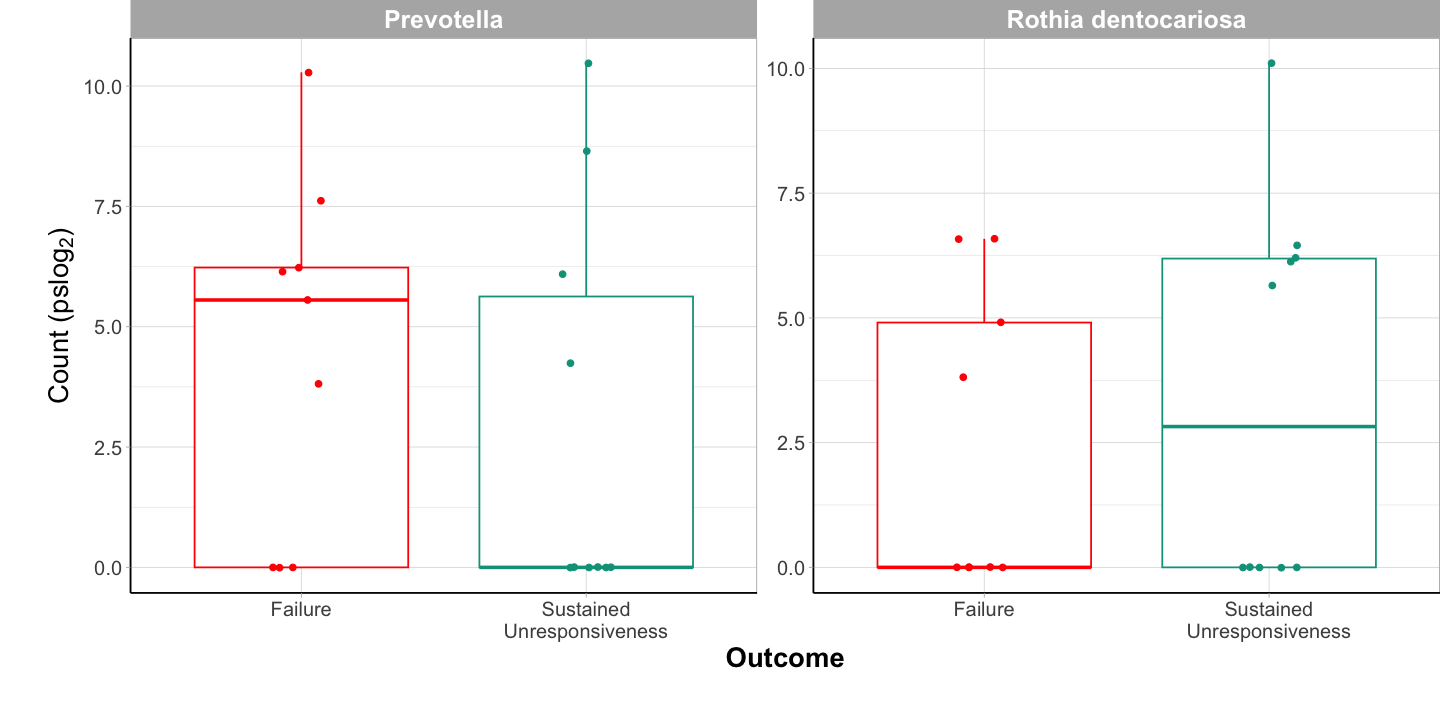

In [5]:
options(repr.plot.width=12, repr.plot.height=6) #changing size

col_palette1 = wes_palette("Darjeeling1", 4, type = "discrete")

saliva_plots = ggplot(data = boxplot_saliva_df , aes(x = Outcome, y = log2(Value + 1), color = Outcome)) + 
  geom_boxplot() + 
  geom_point(position = position_jitter(w = 0.1)) +
  # changing y limits of what is visible in the plot
 # ylim(0, 425) + 

  facet_wrap(~Name1, scales = 'free') + 

  theme_light() + 
  theme(axis.line = element_line(colour = "black"), #making x and y axes black
        axis.text = element_text(size = 12), #changing size of x axis labels
        legend.position = 'none', # removes legend
        plot.margin = unit(c(0,0,2,2), "lines"), # adding space at the bottom of the figure
        axis.title = element_text(face = "bold", size = rel(1.5)),
        strip.text.x = element_text(size = 15, face = "bold"), #changes size of facet x axis 
        strip.text.y = element_text(size = 15, face = "bold")) + #changes axis titles

  labs(y = expression("Count ("*pslog[2]*")")) + 
  scale_colour_manual(values = col_palette1) 

saliva_plots

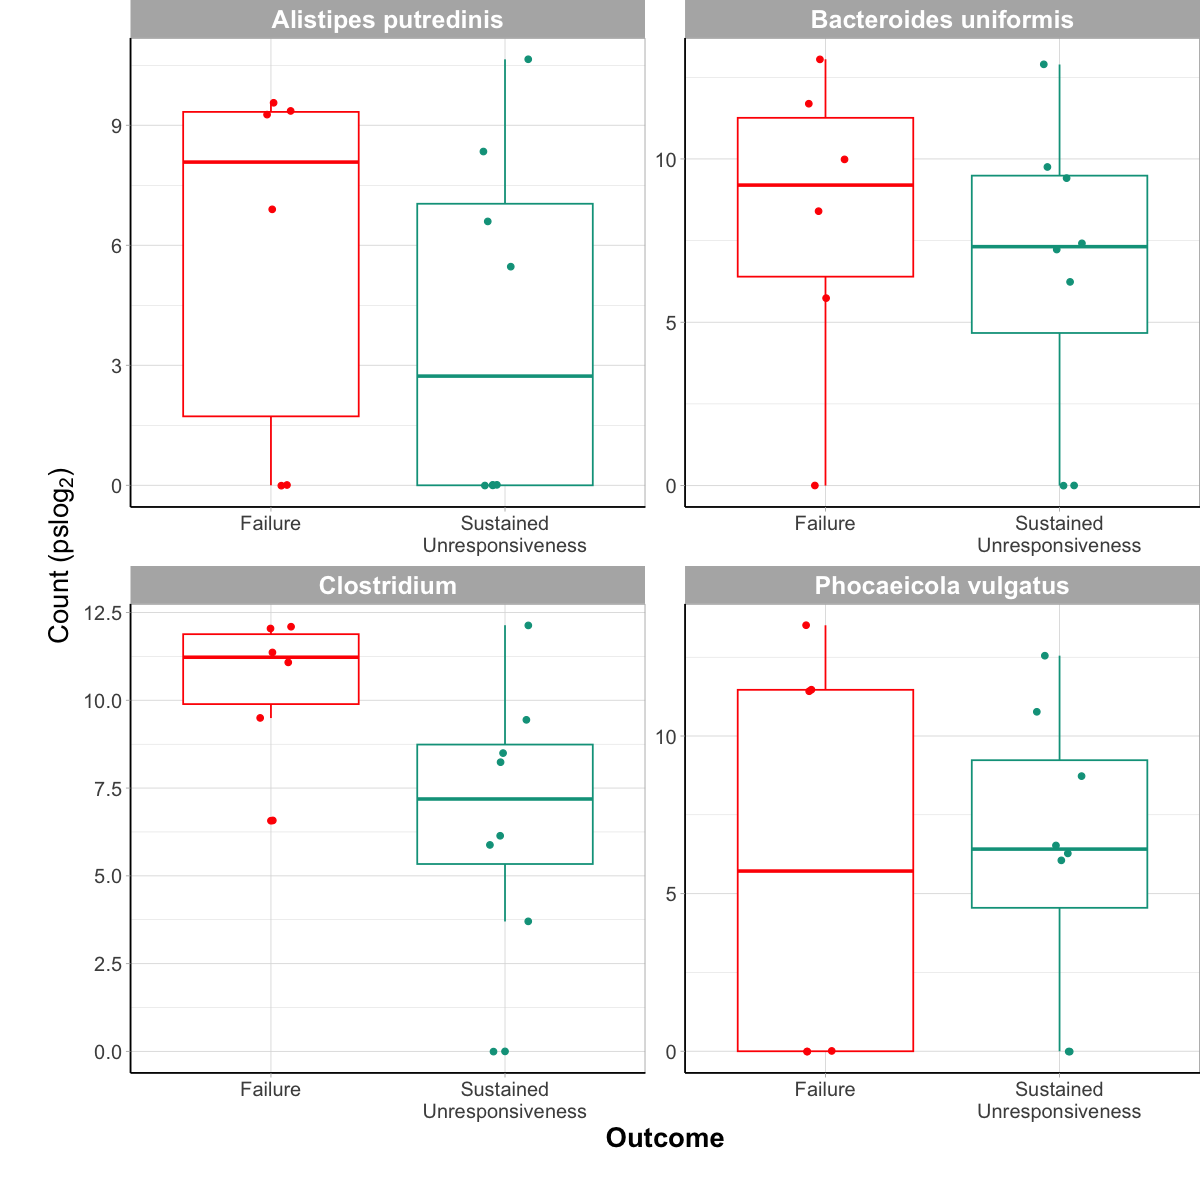

In [6]:
options(repr.plot.width=10, repr.plot.height=10) #changing size

stool_plots = ggplot(data = boxplot_stool_df , aes(x = Outcome, y = log2(Value + 1), color = Outcome)) + 
  geom_boxplot() + 
  geom_point(position = position_jitter(w = 0.1)) +
  # changing y limits of what is visible in the plot
 # ylim(0, 425) + 

  facet_wrap(~Name1, scales = 'free', ncol = 2) + 

  theme_light() + 
  theme(axis.line = element_line(colour = "black"), #making x and y axes black
        axis.text = element_text(size = 12), #changing size of x axis labels
        legend.position = 'none', # removes legend
        plot.margin = unit(c(0,0,2,2), "lines"), # adding space at the bottom of the figure
        axis.title = element_text(face = "bold", size = rel(1.5)),
        strip.text.x = element_text(size = 15, face = "bold"), #changes size of facet x axis 
        strip.text.y = element_text(size = 15, face = "bold")) + #changes axis titles

  labs(y = expression("Count ("*pslog[2]*")")) + 
  scale_colour_manual(values = col_palette1) 

stool_plots